In [48]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import re

In [14]:
df=pd.read_csv(r"E:\NLP_Project\dataset\dataset-tickets-multi-lang-4-20k.csv")

In [15]:
df.head

<bound method NDFrame.head of                                                  subject  \
0      Unvorhergesehener Absturz der Datenanalyse-Pla...   
1                               Customer Support Inquiry   
2                          Data Analytics for Investment   
3                     Krankenhaus-Dienstleistung-Problem   
4                                               Security   
...                                                  ...   
19995     Assistance Needed for IFTTT Docker Integration   
19996        Bitten um Unterstützung bei der Integration   
19997                                                NaN   
19998            Hilfe bei digitalen Strategie-Problemen   
19999  Optimierung Ihrer Datenanalyse-Plattform erlei...   

                                                    body  \
0      Die Datenanalyse-Plattform brach unerwartet ab...   
1      Seeking information on digital strategies that...   
2      I am contacting you to request information on ...   
3      Ei

In [16]:
df.shape

(20000, 15)

In [22]:
df.isnull()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
19996,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True
19997,True,False,False,False,False,False,False,False,False,False,False,False,False,True,True
19998,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   18539 non-null  object
 1   body      19998 non-null  object
 2   answer    19996 non-null  object
 3   type      20000 non-null  object
 4   queue     20000 non-null  object
 5   priority  20000 non-null  object
 6   language  20000 non-null  object
 7   tag_1     20000 non-null  object
 8   tag_2     19954 non-null  object
 9   tag_3     19905 non-null  object
 10  tag_4     18461 non-null  object
 11  tag_5     13091 non-null  object
 12  tag_6     7351 non-null   object
 13  tag_7     3928 non-null   object
 14  tag_8     1907 non-null   object
dtypes: object(15)
memory usage: 2.3+ MB


In [30]:
df.isnull().sum()

subject      1461
body            2
answer          4
type            0
queue           0
priority        0
language        0
tag_1           0
tag_2          46
tag_3          95
tag_4        1539
tag_5        6909
tag_6       12649
tag_7       16072
tag_8       18093
dtype: int64

In [26]:
print(df['queue'].value_counts())

queue
Technical Support                  5824
Product Support                    3708
Customer Service                   3152
IT Support                         2292
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
Human Resources                     338
General Inquiry                     263
Name: count, dtype: int64


In [27]:
print(df[['queue', 'subject', 'body']].head(10))

               queue                                            subject  \
0    General Inquiry  Unvorhergesehener Absturz der Datenanalyse-Pla...   
1   Customer Service                           Customer Support Inquiry   
2   Customer Service                      Data Analytics for Investment   
3   Customer Service                 Krankenhaus-Dienstleistung-Problem   
4   Customer Service                                           Security   
5  Technical Support  Concerns About Securing Medical Data on 2-in-1...   
6  Technical Support  Ratung für Sicherung medizinischer Daten in Hu...   
7         IT Support                           Problem with Integration   
8    Product Support                                 Assistance Request   
9    Product Support                                    Support Request   

                                                body  
0  Die Datenanalyse-Plattform brach unerwartet ab...  
1  Seeking information on digital strategies that...  
2  I am c

In [31]:
df['subject']=df['subject'].fillna("")
df['body']=df['body'].fillna("")

In [32]:
df.isnull().sum()

subject         0
body            0
answer          4
type            0
queue           0
priority        0
language        0
tag_1           0
tag_2          46
tag_3          95
tag_4        1539
tag_5        6909
tag_6       12649
tag_7       16072
tag_8       18093
dtype: int64

In [33]:
df["text"] = df["subject"] + " " + df["body"]

In [34]:
df.head()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN,Unvorhergesehener Absturz der Datenanalyse-Pla...
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN,Customer Support Inquiry Seeking information o...
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN,Data Analytics for Investment I am contacting ...
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN,Krankenhaus-Dienstleistung-Problem Ein Medien-...
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN,"Security Dear Customer Support, I am reaching ..."


In [37]:
df["text"] = df["text"].str.lower()

In [38]:
df.head(10)

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN,unvorhergesehener absturz der datenanalyse-pla...
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN,customer support inquiry seeking information o...
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN,data analytics for investment i am contacting ...
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN,krankenhaus-dienstleistung-problem ein medien-...
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN,"security dear customer support, i am reaching ..."
5,Concerns About Securing Medical Data on 2-in-1...,Inquiring about best practices for securing me...,Thank you for your concern regarding securing ...,Request,Technical Support,medium,en,Security,Product,Feature,IT,Tech Support,NaN,NaN,NaN,concerns about securing medical data on 2-in-1...
6,Ratung für Sicherung medizinischer Daten in Hu...,"Ratung, ob es möglich ist, Sicherung medizinis...","Wir freuen uns, Ihnen zu raten, Sicherung medi...",Request,Technical Support,medium,de,Backup,Security,IT,Tech Support,NaN,NaN,NaN,NaN,ratung für sicherung medizinischer daten in hu...
7,Problem with Integration,"The integration stopped working unexpectedly, ...",I will look into the problem and call you at <...,Problem,IT Support,high,en,Technical,Integration,Bug,Resolution,Outage,Documentation,NaN,NaN,problem with integration the integration stopp...
8,Assistance Request,"Dear Customer Support, I am writing in regards...",I have received your report about the data blo...,Problem,Product Support,high,de,Technical,Bug,Security,Maintenance,Documentation,Resolution,NaN,NaN,"assistance request dear customer support, i am..."
9,Support Request,The latest data analysis reports are inconsist...,Please provide additional details for further ...,Problem,Product Support,high,de,Bug,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,support request the latest data analysis repor...


In [51]:
def clean_punctuation(text):
    return re.sub(r"[^a-zA-Z0-9\s]", "", text)

df["text"] = df["text"].apply(clean_punctuation)

In [52]:
df.head(10)

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN,unvorhergesehener absturz der datenanalyseplat...
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN,customer support inquiry seeking information o...
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN,data analytics for investment i am contacting ...
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN,krankenhausdienstleistungproblem ein mediendat...
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN,security dear customer support i am reaching o...
5,Concerns About Securing Medical Data on 2-in-1...,Inquiring about best practices for securing me...,Thank you for your concern regarding securing ...,Request,Technical Support,medium,en,Security,Product,Feature,IT,Tech Support,NaN,NaN,NaN,concerns about securing medical data on 2in1 c...
6,Ratung für Sicherung medizinischer Daten in Hu...,"Ratung, ob es möglich ist, Sicherung medizinis...","Wir freuen uns, Ihnen zu raten, Sicherung medi...",Request,Technical Support,medium,de,Backup,Security,IT,Tech Support,NaN,NaN,NaN,NaN,ratung fr sicherung medizinischer daten in hub...
7,Problem with Integration,"The integration stopped working unexpectedly, ...",I will look into the problem and call you at <...,Problem,IT Support,high,en,Technical,Integration,Bug,Resolution,Outage,Documentation,NaN,NaN,problem with integration the integration stopp...
8,Assistance Request,"Dear Customer Support, I am writing in regards...",I have received your report about the data blo...,Problem,Product Support,high,de,Technical,Bug,Security,Maintenance,Documentation,Resolution,NaN,NaN,assistance request dear customer support i am ...
9,Support Request,The latest data analysis reports are inconsist...,Please provide additional details for further ...,Problem,Product Support,high,de,Bug,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,support request the latest data analysis repor...


In [53]:
def clean_whitespaces(text):
    return " ".join(text.split())
df["text"] = df["text"].apply(clean_whitespaces)

In [54]:
df.head(5)

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN,unvorhergesehener absturz der datenanalyseplat...
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN,customer support inquiry seeking information o...
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN,data analytics for investment i am contacting ...
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN,krankenhausdienstleistungproblem ein mediendat...
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN,security dear customer support i am reaching o...


In [55]:
print(df["queue"].value_counts())

queue
Technical Support                  5824
Product Support                    3708
Customer Service                   3152
IT Support                         2292
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
Human Resources                     338
General Inquiry                     263
Name: count, dtype: int64


In [56]:
selected_col=['Technical Support','Billing and Payments','Human Resources','General Inquiry']
df=df[df["queue"].isin(selected_col)].copy()

In [59]:
df.head(50)

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN,unvorhergesehener absturz der datenanalyseplat...
5,Concerns About Securing Medical Data on 2-in-1...,Inquiring about best practices for securing me...,Thank you for your concern regarding securing ...,Request,Technical Support,medium,en,Security,Product,Feature,IT,Tech Support,NaN,NaN,NaN,concerns about securing medical data on 2in1 c...
6,Ratung für Sicherung medizinischer Daten in Hu...,"Ratung, ob es möglich ist, Sicherung medizinis...","Wir freuen uns, Ihnen zu raten, Sicherung medi...",Request,Technical Support,medium,de,Backup,Security,IT,Tech Support,NaN,NaN,NaN,NaN,ratung fr sicherung medizinischer daten in hub...
10,Issue with Data Analytics Platform - Insuffici...,I am reaching out to report an issue with our ...,Your email regarding the data analytics platfo...,Problem,Technical Support,high,en,Technical,Outage,Crash,Resolution,Disruption,Guidance,Documentation,NaN,issue with data analytics platform insufficien...
11,Reported Issue with Project Sync Resulting in ...,"Dear Customer Support,\n\nI am reporting an is...",We will look into the sync issue and contact y...,Incident,Technical Support,high,en,Technical,Bug,DataLoss,SoftwareUpdate,SyncIssue,Resolution,NaN,NaN,reported issue with project sync resulting in ...
12,Strategies for Brand Expansion,"Hello Customer Support Team, I am writing to s...","Greetings [Name], thank you for contacting our...",Request,Technical Support,medium,en,Customer,Strategy,Guidance,Documentation,Feedback,NaN,NaN,NaN,strategies for brand expansion hello customer ...
13,Issue with Website Analytics Dashboard,"Dear Customer Support, I am encountering a pro...","Dear <name>, we regret the inconvenience you h...",Incident,Technical Support,low,en,Technical,Bug,API,Documentation,Resolution,Customer,NaN,NaN,issue with website analytics dashboard dear cu...
14,Urgent: Data Breach Identified in Hospital Net...,"Data breach found, assistance required",Please handle this data breach with urgency. K...,Incident,Technical Support,high,en,Security,Network,Outage,IT,NaN,NaN,NaN,NaN,urgent data breach identified in hospital netw...
17,Problem with Data Analytics Software Frequent ...,The data analytics software used by the financ...,"Dear [Name], we apologize for the frequent cra...",Problem,Technical Support,high,en,Bug,Crash,Performance,Hardware,IT,Tech Support,NaN,NaN,problem with data analytics software frequent ...
20,Notwendige Technische Unterstützung,"Sehr geehrte Kundensupport, wir begegnen momen...","Sehr geehrte [name], danke für Ihre Nachricht....",Problem,Technical Support,medium,de,Tech Support,Performance,IT,Network,NaN,NaN,NaN,NaN,notwendige technische untersttzung sehr geehrt...


In [60]:
print(df["queue"].value_counts())

queue
Technical Support       5824
Billing and Payments    2086
Human Resources          338
General Inquiry          263
Name: count, dtype: int64


In [62]:
X=df['text']
y=df['queue']

In [63]:
from sklearn.model_selection import train_test_split 

In [64]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42,stratify=y)

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [68]:
tfidf = TfidfVectorizer()

In [69]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [70]:
X_test_tfidf = tfidf.transform(X_test)

In [71]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(6808, 13264)
(1703, 13264)


In [73]:
from sklearn.linear_model import LogisticRegression 

In [74]:
logmodel=LogisticRegression(class_weight="balanced",max_iter=1000)

In [75]:
logmodel.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [76]:
prediction=logmodel.predict(X_test_tfidf)

In [85]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [86]:
def measures(y_test, prediction):
    return classification_report(y_test, prediction)

In [104]:
print(measures(y_test, prediction))

                      precision    recall  f1-score   support

Billing and Payments       0.71      0.85      0.77       417
     General Inquiry       0.26      0.62      0.36        53
     Human Resources       0.38      0.50      0.43        68
   Technical Support       0.92      0.78      0.84      1165

            accuracy                           0.78      1703
           macro avg       0.57      0.69      0.60      1703
        weighted avg       0.83      0.78      0.80      1703



In [90]:
accuracy=accuracy_score(y_test, prediction)

In [91]:
print(accuracy)

0.7809747504403993


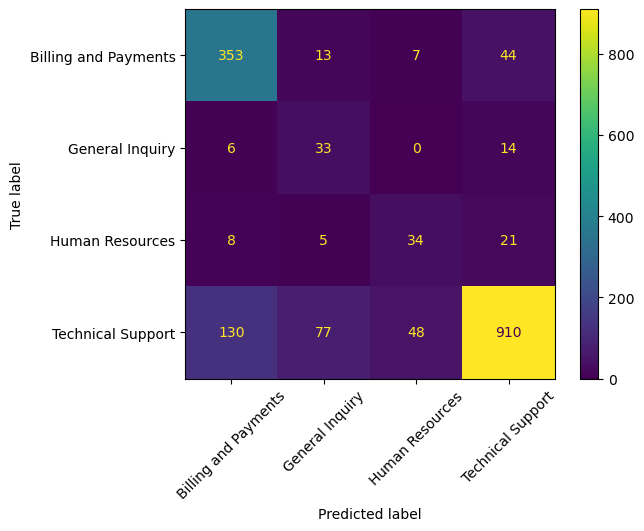

In [103]:
from sklearn.metrics import  ConfusionMatrixDisplay
cm = confusion_matrix(y_test, prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logmodel.classes_
)

disp.plot(xticks_rotation=45)
plt.show()

In [105]:
from sklearn.metrics import f1_score

In [107]:
macro_f1 = f1_score(y_test, prediction, average="macro")

In [109]:
weighted_f1 = f1_score(y_test, prediction, average="weighted")

In [110]:
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.6037826085701246
Weighted F1: 0.7957931472342518
